In [ ]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00


In [ ]:
# CELL 2: Imports and Setup
# ===================================================================
from ultralytics import YOLO
import cv2
import time
import os
import torch
from google.colab import files
from google.colab.patches import cv2_imshow

# Check GPU
print("🔍 Checking GPU availability...")
if torch.cuda.is_available():
    print(f"✅ GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA Version: {torch.version.cuda}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 'cuda'
    half = True  # Use FP16 for faster inference
else:
    print("⚠️ GPU not available. Using CPU (will be slow).")
    device = 'cpu'
    half = False

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔍 Checking GPU availability...
✅ GPU Available: Tesla T4
✅ CUDA Version: 12.6
✅ GPU Memory: 15.83 GB


In [ ]:
# CELL 3: Configuration
# ===================================================================
CONF_THRES = 0.70
IOU_THRES = 0.63
IMG_SIZE = 512
LINE_Y = IMG_SIZE // 2

OUTPUT_PATH = "/content/output_video_fps_test.mp4"

In [ ]:
# CELL 4: Upload Files
# ===================================================================
# Upload model weights
print("📁 Please upload your model weights file (best.pt):")
uploaded_weights = files.upload()
weights_filename = list(uploaded_weights.keys())[0]
WEIGHTS_PATH = f"/content/{weights_filename}"
print(f"✅ Weights uploaded: {WEIGHTS_PATH}")

# Upload video
print("\n📁 Please upload your input video file:")
uploaded_video = files.upload()
video_filename = list(uploaded_video.keys())[0]
VIDEO_PATH = f"/content/{video_filename}"
print(f"✅ Video uploaded: {VIDEO_PATH}")

📁 Please upload your model weights file (best.pt):


Saving best.pt to best.pt
✅ Weights uploaded: /content/best.pt

📁 Please upload your input video file:


Saving New.mp4 to New.mp4
✅ Video uploaded: /content/New.mp4


In [ ]:
# CELL 5: Load Model
# ===================================================================
print(f"\n🤖 Loading YOLO model from: {WEIGHTS_PATH}")
model = YOLO(WEIGHTS_PATH)
model.to(device)  # Move to GPU
print("✅ Model loaded and moved to GPU!")


🤖 Loading YOLO model from: /content/best.pt
✅ Model loaded and moved to GPU!


In [ ]:
# CELL 6: Open Video and Initialize
# ===================================================================
print(f"\n🎬 Opening video: {VIDEO_PATH}")
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("❌ Could not open video file")

video_fps = cap.get(cv2.CAP_PROP_FPS)
if video_fps == 0:
    video_fps = 25

video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"📹 Video Info:")
print(f"   Resolution: {video_width}x{video_height}")
print(f"   FPS: {video_fps:.2f}")
print(f"   Total Frames: {total_frames}")

# Video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    video_fps,
    (IMG_SIZE, IMG_SIZE)
)

print("✅ Video writer initialized!")


🎬 Opening video: /content/New.mp4
📹 Video Info:
   Resolution: 1280x720
   FPS: 29.88
   Total Frames: 2338
✅ Video writer initialized!


In [ ]:
# CELL 7: Initialize Tracking Variables
# ===================================================================
fps_start_time = time.time()
fps_frame_count = 0
fps_display = 0.0
FPS_UPDATE_INTERVAL = 0.5

track_last_side = {}
track_history_y = {}
track_last_frame = {}
track_counted = {}

MAX_TRACK_GAP = 15
CROSSING_COOLDOWN = 25
LINE_TOLERANCE = 5

in_count = 0
out_count = 0
frame_number = 0

In [ ]:
# CELL 8: Main Processing Loop
# ===================================================================
print("\n🔄 Starting video processing...")
print("=" * 60)
processing_start = time.time()

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_number += 1
        fps_frame_count += 1

        # Resize frame
        frame_resized = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        annotated_frame = frame_resized.copy()

        # YOLO tracking with GPU optimization
        results = model.track(
            source=frame_resized,
            conf=CONF_THRES,
            iou=IOU_THRES,
            persist=True,
            tracker="bytetrack.yaml",
            verbose=False,
            device=device,
            half=half,
            imgsz=IMG_SIZE,
        )

        # Process detections
        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.cpu().numpy().astype(int)
            classes = results[0].boxes.cls.cpu().numpy()

            for box, track_id, cls in zip(boxes, track_ids, classes):
                if int(cls) != 0:
                    continue

                x1, y1, x2, y2 = box
                center_y = int((y1 + y2) / 2)

                # Draw bounding box
                cv2.rectangle(annotated_frame,
                              (int(x1), int(y1)),
                              (int(x2), int(y2)),
                              (0, 255, 0), 2)

                # Draw track ID
                cv2.putText(annotated_frame,
                            f"ID {track_id}",
                            (int(x1), int(y1) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.6, (0, 255, 0), 2)

                current_side = "above" if center_y < LINE_Y else "below"

                if track_id not in track_counted:
                    track_counted[track_id] = {"IN": 0, "OUT": 0}

                if track_id in track_history_y:
                    prev_y = track_history_y[track_id]
                    prev_side = track_last_side.get(track_id)

                    line_top = LINE_Y - LINE_TOLERANCE
                    line_bottom = LINE_Y + LINE_TOLERANCE

                    line_crossed = False
                    crossing_type = None

                    if prev_y < line_top and center_y > line_bottom:
                        line_crossed = True
                        crossing_type = "IN"
                    elif prev_y > line_bottom and center_y < line_top:
                        line_crossed = True
                        crossing_type = "OUT"

                    if not line_crossed and prev_side:
                        if prev_side == "above" and current_side == "below":
                            line_crossed = True
                            crossing_type = "IN"
                        elif prev_side == "below" and current_side == "above":
                            line_crossed = True
                            crossing_type = "OUT"

                    if line_crossed:
                        last_counted = track_counted[track_id].get(crossing_type, 0)
                        if last_counted == 0 or frame_number - last_counted >= CROSSING_COOLDOWN:
                            if crossing_type == "IN":
                                in_count += 1
                                track_counted[track_id]["IN"] = frame_number
                            else:
                                out_count += 1
                                in_count = max(0, in_count - 1)
                                track_counted[track_id]["OUT"] = frame_number

                track_last_side[track_id] = current_side
                track_history_y[track_id] = center_y
                track_last_frame[track_id] = frame_number

        # Update FPS
        elapsed = time.time() - fps_start_time
        if elapsed >= FPS_UPDATE_INTERVAL:
            fps_display = fps_frame_count / elapsed
            fps_start_time = time.time()
            fps_frame_count = 0

        # Draw overlays
        cv2.line(annotated_frame,
                 (0, LINE_Y),
                 (IMG_SIZE, LINE_Y),
                 (0, 0, 255), 2)

        cv2.putText(annotated_frame,
                    f"IN: {in_count}",
                    (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 255, 0), 2)

        cv2.putText(annotated_frame,
                    f"OUT: {out_count}",
                    (20, 80),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 0, 255), 2)

        cv2.putText(annotated_frame,
                    f"FPS: {fps_display:.1f}",
                    (IMG_SIZE - 150, 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1, (255, 255, 0), 2)

        # Progress indicator every 30 frames
        if frame_number % 30 == 0:
            progress = (frame_number / total_frames) * 100
            elapsed_time = time.time() - processing_start
            eta = (elapsed_time / frame_number) * (total_frames - frame_number)
            print(f"⏳ Progress: {progress:5.1f}% | "
                  f"Frame: {frame_number:5d}/{total_frames} | "
                  f"FPS: {fps_display:5.1f} | "
                  f"IN: {in_count:3d} | OUT: {out_count:3d} | "
                  f"ETA: {eta:.1f}s")

        writer.write(annotated_frame)

except KeyboardInterrupt:
    print("\n⚠️ Processing interrupted by user")

# Cleanup
cap.release()
writer.release()


🔄 Starting video processing...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 162ms
Prepared 1 package in 61ms
Installed 1 package in 3ms
 + lap==0.5.12

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

⏳ Progress:   1.3% | Frame:    30/2338 | FPS:  57.7 | IN:   0 | OUT:   0 | ETA: 506.2s
⏳ Progress:   2.6% | Frame:    60/2338 | FPS:  57.7 | IN:   0 | OUT:   0 | ETA: 268.5s
⏳ Progress:   3.8% | Frame:    90/2338 | FPS:  60.8 | IN:   0 | OUT:   0 | ETA: 189.3s
⏳ Progress:   5.1% | Frame:   120/2338 | FPS:  59.5 | IN:   0 | OUT:   0 | ETA: 149.2s
⏳ Progress:   6.4% | Frame:   150/2338 | FPS:  60.9 | IN:   0 | OUT:   0 | ETA: 125.1s
⏳ Progress:   7.7% | Frame:   180/2338 | FPS:  59.4 | IN:   0 | OUT:   0 | ETA: 108.7s
⏳ Progress:   9.0% | Frame:   210/2338 | FPS:  60.5 | IN:   0 | OUT:   0 | ETA: 97.1s
⏳ P

In [ ]:
# CELL 9: Results Summary
# ===================================================================
processing_time = time.time() - processing_start
avg_fps = frame_number / processing_time

print("\n" + "=" * 60)
print("✅ VIDEO PROCESSING COMPLETED!")
print("=" * 60)
print(f"⏱️  Total processing time: {processing_time:.2f} seconds ({processing_time/60:.2f} minutes)")
print(f"📊 Average FPS: {avg_fps:.2f}")
print(f"📈 Final counts - IN: {in_count} | OUT: {out_count}")
print(f"💾 Output saved to: {OUTPUT_PATH}")
print("=" * 60)


✅ VIDEO PROCESSING COMPLETED!
⏱️  Total processing time: 59.09 seconds (0.98 minutes)
📊 Average FPS: 39.57
📈 Final counts - IN: 1 | OUT: 4
💾 Output saved to: /content/output_video_fps_test.mp4



📹 Preview of output video (first frame):


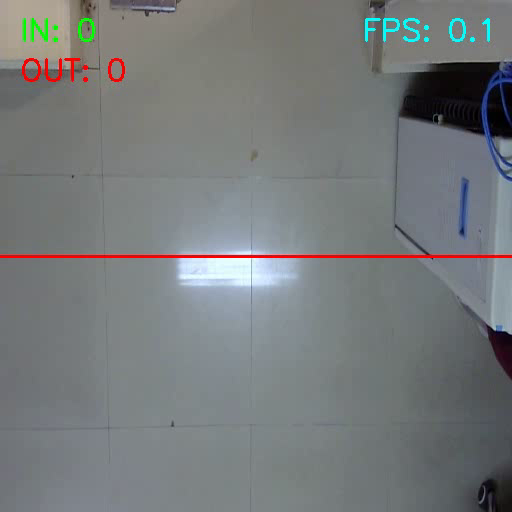

In [ ]:
# CELL 10: Preview Output (Optional)
# ===================================================================
# Display first frame as preview
cap_out = cv2.VideoCapture(OUTPUT_PATH)
ret, preview_frame = cap_out.read()
if ret:
    print("\n📹 Preview of output video (first frame):")
    cv2_imshow(preview_frame)
cap_out.release()

In [ ]:
# CELL 11: Download Output Video
# ===================================================================
print("\n📥 Downloading output video...")
files.download(OUTPUT_PATH)
print("✅ Download complete!")


📥 Downloading output video...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download complete!
